In [ ]:
required_packages = ["LinearAlgebra", "Statistics", "MAT", "Random", "Plots", "PyPlot","Measures"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

┌ Warning: MAT not found, installing...
└ @ Main In[1]:6
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed MPIPreferences ──────── v0.1.11
   Installed MicrosoftMPI_jll ────── v10.1.4+3
   Installed Hwloc_jll ───────────── v2.13.0+0
   Installed MPICH_jll ───────────── v4.3.2+0
   Installed StringEncodings ─────── v0.3.7
   Installed HDF5_jll ────────────── v1.14.6+0
   Installed MAT ─────────────────── v0.11.5
   Installed OpenMPI_jll ─────────── v5.0.9+0
   Installed XML2_jll ────────────── v2.13.9+0
   Installed libaec_jll ──────────── v1.1.5+0
   Installed MPItrampoline_jll ───── v5.5.5+0
   Installed HDF5 ────────────────── v0.17.2
    Updating `~/.julia/environments/v1.11/Project.toml`
  [23992714] + MAT v0.11.5
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [f67ccb44] + HDF5 v0.17.2
  [23992714] + MAT v0.11.5
  [3da0fdf6] + MPIPreferences v0.1.11
  [69024149] + Stri

In [ ]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using LinearAlgebra
using Statistics
using MAT
using Random
using PyPlot
using Measures


#_________________________________setting problem______________________________#
Random.seed!(23)

m = 500
n = 400
r = 30
max_iter = 3000

println("="^70)
println("Matrix Factorization: min 0.5*||UV'-Y||_F^2")
println("  s.t. ||U||_op ≤ τ₁,  ||V||_op ≤ τ₂")
println("="^70)
println("Dimensions: m=$m, n=$n, r=$r")

# Ill-conditioned singular values (log-spaced)
sigma_max = 10.0
sigma_min = 0.01
sigmas = exp.(range(log(sigma_max), log(sigma_min), length=r)) |> collect
Sigma_half = Diagonal(sqrt.(sigmas))
println("κ = $(round(sigma_max/sigma_min, digits=0))")

# Orthonormal bases
Random.seed!(23)
U_bar, _ = qr(randn(m, r)); U_bar = Matrix(U_bar)[:, 1:r]
V_bar, _ = qr(randn(n, r)); V_bar = Matrix(V_bar)[:, 1:r]

# Ground truth
U_star = U_bar * Sigma_half
V_star = V_bar * Sigma_half
Y = U_star * V_star'

# Tight constraints
tau1 = ceil(Int, opnorm(U_star))
tau2 = ceil(Int, opnorm(V_star))

println("τ₁ = $tau1, τ₂ = $tau2")
println("||U*||_op = $(round(opnorm(U_star), digits=4))")
println("||V*||_op = $(round(opnorm(V_star), digits=4))")

@assert opnorm(U_star) <= tau1
@assert opnorm(V_star) <= tau2

# Problem functions
function f_matfac(U, V)
    R = U * V' - Y
    return 0.5 * norm(R)^2
end

function grad_f_matfac(U, V)
    R = U * V' - Y
    return R * V, R' * U
end

function lmo_spectral(G, tau)
    F = svd(G)
    return -tau * F.U * F.Vt
end

function lmo_matfac(grad_U, grad_V)
    return lmo_spectral(grad_U, tau1), lmo_spectral(grad_V, tau2)
end

function fro_inner(A, B); return dot(A, B); end
function fro_norm2_concat(A, B); return norm(A)^2 + norm(B)^2; end
function fro_norm_concat(A, B); return sqrt(fro_norm2_concat(A, B)); end

function project_spectral(X, tau)
    F = svd(X)
    return F.U * Diagonal(min.(F.S, tau)) * F.Vt
end

# Initial point: at constraint boundary, far from optimum
Random.seed!(23)
U0 = project_spectral(10.0 * randn(m, r), tau1)
V0 = project_spectral(10.0 * randn(n, r), tau2)

L_global = max(tau1^2, tau2^2) + opnorm(Y) + tau1 * tau2

println("\nf(U0,V0) = $(round(f_matfac(U0, V0), digits=4))")
println("f(U*,V*) = $(round(f_matfac(U_star, V_star), digits=6))  (optimal = 0)")
println("L_global = $(round(L_global, digits=4))")
println("max_iter = $max_iter")
println("="^70)

Matrix Factorization: min 0.5*||UV'-Y||_F^2
  s.t. ||U||_op ≤ τ₁,  ||V||_op ≤ τ₂
Dimensions: m=500, n=400, r=30
κ = 1000.0
τ₁ = 4, τ₂ = 4
||U*||_op = 3.1623
||V*||_op = 3.1623

f(U0,V0) = 3778.9703
f(U*,V*) = 0.0  (optimal = 0)
L_global = 42.0
max_iter = 3000


In [ ]:
#______________________________________________________________________________#
#__________________________________Main Functions______________________________#
#______________________________________________________________________________#

#___________ __FW: Adaptive step-size with constant scaling____________________#
function conditional_gradient_adaptive_matfac(f, grad_f, lmo, U0, V0, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[34m________Adaptive step-size: with constant scaling (Matrix Factorization)_________")
    U_prev = copy(U0)
    V_prev = copy(V0)
    U_curr = copy(U0)
    V_curr = copy(V0)
    current_f = f(U_curr, V_curr)
    values = [current_f]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0

    prev_grad_U, prev_grad_V = grad_f(U_prev, V_prev)

    while k < max_iter
        start = time()

        # Compute gradient
        curr_grad_U, curr_grad_V = grad_f(U_curr, V_curr)

        # LMO
        P, Q = lmo(curr_grad_U, curr_grad_V)

        # FW direction
        dU = P - U_curr
        dV = Q - V_curr

        # FW gap: -<grad, d> = -(<grad_U, dU> + <grad_V, dV>)
        normd2 = fro_norm2_concat(dU, dV)
        gap = -(fro_inner(curr_grad_U, dU) + fro_inner(curr_grad_V, dV))

        if gap <= epsilon
            println(">>>  ____________________     Terminated at k=$k, Dual Gap: $(round(gap, digits=4))____________________")
            iteration_time = time() - start
            push!(times, iteration_time)
            push!(gaps, gap)
            break
        end

        # Estimate local Lipschitz constant
        if k == 0
            Random.seed!(23)
            dU0 = randn(size(U0))
            dV0 = randn(size(V0))
            norm_d0 = fro_norm_concat(dU0, dV0)
            eps_fd = 1e-3
            g1_U, g1_V = grad_f(U0, V0)
            g2_U, g2_V = grad_f(U0 + eps_fd * dU0, V0 + eps_fd * dV0)
            grad_diff_norm = fro_norm_concat(g2_U - g1_U, g2_V - g1_V)
            L_k = gamma * (grad_diff_norm / (eps_fd * norm_d0) + delta)
        else
            grad_diff_norm = fro_norm_concat(curr_grad_U - prev_grad_U, curr_grad_V - prev_grad_V)
            x_diff_norm = fro_norm_concat(U_curr - U_prev, V_curr - V_prev)
            L_k = gamma * (grad_diff_norm / x_diff_norm + delta)
        end

        Lknormd2 = L_k * normd2
        t_k = min(gap / Lknormd2, 1.0)

        # Backtracking
        i = 0
        while true
            U_new = U_curr + t_k * dU
            V_new = V_curr + t_k * dV
            new_f = f(U_new, V_new)
            quad_bound = t_k * gap - (Lknormd2 / 2) * t_k^2

            if current_f - new_f >= quad_bound
                U_prev = copy(U_curr)
                V_prev = copy(V_curr)
                U_curr = U_new
                V_curr = V_new
                push!(backtrack_counts, i)
                break
            else
                L_k *= beta
                Lknormd2 = L_k * normd2
                t_k = min(gap / Lknormd2, 1.0)
                i += 1
            end
        end

        k += 1
        iteration_time = time() - start

        current_f = f(U_curr, V_curr)
        prev_grad_U = curr_grad_U
        prev_grad_V = curr_grad_V
        push!(gaps, gap)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end

    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (γ=$gamma):")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Max L_k 2: $(round(maximum(L_ks[2:end]), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("Mean L_k 2: $(round(mean(L_ks[2:end]), digits=6))")
    println("____________________________________________________________\e[0m")
    return (U_curr, V_curr, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#

#____________FW: Adaptive step-size with adjustable scaling____________________#
function conditional_gradient_adjustable_scaling_matfac(f, grad_f, lmo, U0, V0, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[33m_____________________Adaptive step-size with adjustable scaling (Matrix Factorization)_____________________")
    U_prev = copy(U0)
    V_prev = copy(V0)
    U_curr = copy(U0)
    V_curr = copy(V0)
    current_f = f(U_curr, V_curr)
    values = [current_f]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    gamma_history = [gamma]
    k = 0

    prev_grad_U, prev_grad_V = grad_f(U_prev, V_prev)
    recent_backtracks = Int[]

    while k < max_iter
        start = time()

        curr_grad_U, curr_grad_V = grad_f(U_curr, V_curr)
        P, Q = lmo(curr_grad_U, curr_grad_V)

        dU = P - U_curr
        dV = Q - V_curr
        normd2 = fro_norm2_concat(dU, dV)
        gap = -(fro_inner(curr_grad_U, dU) + fro_inner(curr_grad_V, dV))

        if gap <= epsilon
            println(">>> ____________________      Terminated at k=$k, Dual Gap: $(round(gap, digits=4))  ____________________")
            iteration_time = time() - start
            push!(times, iteration_time)
            push!(gaps, gap)
            break
        end

        if k == 0
            Random.seed!(23)
            dU0 = randn(size(U0))
            dV0 = randn(size(V0))
            norm_d0 = fro_norm_concat(dU0, dV0)
            eps_fd = 1e-3
            g1_U, g1_V = grad_f(U0, V0)
            g2_U, g2_V = grad_f(U0 + eps_fd * dU0, V0 + eps_fd * dV0)
            grad_diff_norm = fro_norm_concat(g2_U - g1_U, g2_V - g1_V)
            L_k = gamma * (grad_diff_norm / (eps_fd * norm_d0) + delta)
        else
            grad_diff_norm = fro_norm_concat(curr_grad_U - prev_grad_U, curr_grad_V - prev_grad_V)
            x_diff_norm = fro_norm_concat(U_curr - U_prev, V_curr - V_prev)
            L_k = gamma * (grad_diff_norm / x_diff_norm + delta)
        end

        Lknormd2 = L_k * normd2
        t_k = min(gap / Lknormd2, 1.0)

        i = 0
        while true
            U_new = U_curr + t_k * dU
            V_new = V_curr + t_k * dV
            new_f = f(U_new, V_new)

            if current_f - new_f >= t_k * gap - (Lknormd2 / 2) * t_k^2
                U_prev = copy(U_curr)
                V_prev = copy(V_curr)
                U_curr = U_new
                V_curr = V_new
                push!(backtrack_counts, i)
                push!(recent_backtracks, i)
                break
            else
                L_k *= beta
                Lknormd2 = L_k * normd2
                t_k = min(gap / Lknormd2, 1.0)
                i += 1
            end
        end

        # Adaptive gamma adjustment every 10 iterations
        if k % 10 == 0 && k > 0
            total_backtracks = sum(recent_backtracks)
            if total_backtracks == 0
                gamma = gamma * 0.9
            elseif total_backtracks > 10
                gamma = min(1, gamma * 1.1)
            end
            push!(gamma_history, gamma)
            recent_backtracks = Int[]
        elseif k % 10 == 0
            push!(gamma_history, gamma)
            recent_backtracks = Int[]
        else
            push!(recent_backtracks, i)
        end

        k += 1
        iteration_time = time() - start

        current_f = f(U_curr, V_curr)
        prev_grad_U = curr_grad_U
        prev_grad_V = curr_grad_V
        push!(gaps, gap)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end

    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (final γ=$(round(gamma, digits=4))):")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (U_curr, V_curr, values, times, gaps, L_ks, backtrack_counts, steps, gamma_history)
end
#______________________________________________________________________________#

#___________________________FW: Pure backtracking step-size____________________#
function conditional_gradient_Pedregosa_matfac(f, grad_f, lmo, U0, V0, max_iter; epsilon=1e-5)
    println("\e[31m_____________________Pure backtracking step-size (Matrix Factorization)_____________")
    U_prev = copy(U0)
    V_prev = copy(V0)
    current_f = f(U_prev, V_prev)
    values = [current_f]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    tau_bt = 2.0
    eta = 0.9

    # Initial L estimate
    Random.seed!(23)
    dU0 = randn(size(U0))
    dV0 = randn(size(V0))
    norm_d0 = fro_norm_concat(dU0, dV0)
    eps_fd = 1e-3
    g1_U, g1_V = grad_f(U0, V0)
    g2_U, g2_V = grad_f(U0 + eps_fd * dU0, V0 + eps_fd * dV0)
    grad_diff_norm = fro_norm_concat(g2_U - g1_U, g2_V - g1_V)
    L_minus1 = grad_diff_norm / (eps_fd * norm_d0)
    M = L_minus1 * eta

    while k < max_iter
        start = time()

        grad_U, grad_V = grad_f(U_prev, V_prev)
        P, Q = lmo(grad_U, grad_V)

        dU = P - U_prev
        dV = Q - V_prev
        normd2 = fro_norm2_concat(dU, dV)
        gap = -(fro_inner(grad_U, dU) + fro_inner(grad_V, dV))

        f_prev = current_f

        if gap <= epsilon
            println(">>>  ____________________     Terminated at k=$k, Dual Gap: $(round(gap, digits=4))   ____________________")
            iteration_time = time() - start
            push!(times, iteration_time)
            push!(gaps, gap)
            break
        end

        t_k = min(gap / (M * normd2), 1.0)
        i = 0
        U_new = U_prev
        V_new = V_prev
        while true
            U_new = U_prev + t_k * dU
            V_new = V_prev + t_k * dV
            f_new = f(U_new, V_new)
            if f_prev - f_new >= t_k * gap - (M / 2) * t_k^2 * normd2
                push!(backtrack_counts, i)
                break
            else
                M *= tau_bt
                t_k = min(gap / (M * normd2), 1.0)
                i += 1
            end
        end

        U_prev = U_new
        V_prev = V_new
        k += 1
        iteration_time = time() - start

        current_f = f(U_new, V_new)
        push!(gaps, gap)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, M)
        push!(steps, t_k)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), M = $(round(M, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=4))")
        end
        M = M * eta
    end

    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Pedregosa Method:")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=4))")
    println("Mean L_k: $(round(mean(L_ks), digits=4))")
    println("____________________________________________________________\e[0m")
    return (U_prev, V_prev, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#

#_____________________________FW: Open step-size_______________________________#
function conditional_gradient_open_matfac(f, grad_f, lmo, U0, V0, max_iter; epsilon=1e-5)
    println("\e[36m____________________Open step-size (Matrix Factorization)_________________________")
    U = copy(U0)
    V = copy(V0)
    values = [f(U, V)]
    times = [0.0]
    gaps = Float64[]
    steps = Float64[]
    k = 0
    while k < max_iter
        start = time()

        grad_U, grad_V = grad_f(U, V)
        P, Q = lmo(grad_U, grad_V)

        dU = P - U
        dV = Q - V
        gap = -(fro_inner(grad_U, dU) + fro_inner(grad_V, dV))

        if gap <= epsilon
            println(">>> ____________________      Terminated at k=$k, Dual Gap: $(round(gap, digits=4))____________________")
            iteration_time = time() - start
            push!(times, iteration_time)
            push!(gaps, gap)
            break
        end

        t_k = 1 / sqrt(1 + k)
        U = U + t_k * dU
        V = V + t_k * dV
        k += 1

        current_f = f(U, V)
        iteration_time = time() - start
        push!(gaps, gap)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(steps, t_k)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), Time = $(round(iteration_time, digits=2)) sec, f_k = $(round(current_f, digits=4))")
        end
    end

    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Open Loop Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(U, V), digits=6))")
    println("____________________________________________________________\e[0m")
    return (U, V, values, times, gaps, steps)
end
#______________________________________________________________________________#

#________________________________FW: Short step-size___________________________#
function conditional_gradient_short_step_matfac(f, grad_f, lmo, U0, V0, L, max_iter; epsilon=1e-5)
    println("\e[35m____________________Short step-size (Matrix Factorization)________________________")
    U = copy(U0)
    V = copy(V0)
    values = [f(U, V)]
    times = [0.0]
    gaps = Float64[]
    steps = Float64[]
    k = 0
    while k < max_iter
        start = time()

        grad_U, grad_V = grad_f(U, V)
        P, Q = lmo(grad_U, grad_V)

        dU = P - U
        dV = Q - V
        normd2 = fro_norm2_concat(dU, dV)
        gap = -(fro_inner(grad_U, dU) + fro_inner(grad_V, dV))

        if gap <= epsilon
            println(">>> ____________________      Terminated at k=$k, Dual Gap: $(round(gap, digits=4))____________________")
            iteration_time = time() - start
            push!(times, iteration_time)
            push!(gaps, gap)
            break
        end

        t_k = min(gap / (L * normd2), 1.0)
        U = U + t_k * dU
        V = V + t_k * dV
        k += 1

        current_f = f(U, V)
        iteration_time = time() - start
        push!(gaps, gap)
        push!(values, current_f)
        push!(steps, t_k)
        push!(times, iteration_time)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=4))")
        end
    end

    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Short Step Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(U, V), digits=6))")
    println("____________________________________________________________\e[0m")
    return (U, V, values, times, gaps, steps)
end
#______________________________________________________________________________#

conditional_gradient_short_step_matfac (generic function with 1 method)

In [ ]:
# Ensure all necessary packages are loaded
using LinearAlgebra
using Statistics
using MAT
using Random
using PyPlot
using Measures
using Measures

#______________________________________________________________________________#
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output_matfac"
mkpath(output_dir)
#____________________________________Run_______________________________________#

# Adaptive constant scaling
results_our = conditional_gradient_adaptive_matfac(f_matfac, grad_f_matfac, lmo_matfac, U0, V0, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR.mat"), Dict(
    "U" => results_our[1], "V" => results_our[2],
    "values" => results_our[3], "times" => results_our[4],
    "gaps" => results_our[5], "L_ks" => results_our[6],
    "backtrack_counts" => results_our[7], "steps" => results_our[8]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR.mat"))

#____________
# Adaptive adjustable scaling
results_our5 = conditional_gradient_adjustable_scaling_matfac(f_matfac, grad_f_matfac, lmo_matfac, U0, V0, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR_5.mat"), Dict(
    "U" => results_our5[1], "V" => results_our5[2],
    "values" => results_our5[3], "times" => results_our5[4],
    "gaps" => results_our5[5], "L_ks" => results_our5[6],
    "backtrack_counts" => results_our5[7], "steps" => results_our5[8],
    "gamma_history" => results_our5[9]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR_5.mat"))

#____________
# Pure backtracking (Pedregosa)
results_ped = conditional_gradient_Pedregosa_matfac(f_matfac, grad_f_matfac, lmo_matfac, U0, V0, max_iter)
MAT.matwrite(joinpath(output_dir, "results_FW_Pedregosa.mat"), Dict(
    "U" => results_ped[1], "V" => results_ped[2],
    "values" => results_ped[3], "times" => results_ped[4],
    "gaps" => results_ped[5], "L_ks" => results_ped[6],
    "backtrack_counts" => results_ped[7], "steps" => results_ped[8]
))
println("Saved: ", joinpath(output_dir, "results_FW_Pedregosa.mat"))

#____________
# Short-step
results_short = conditional_gradient_short_step_matfac(f_matfac, grad_f_matfac, lmo_matfac, U0, V0, L_global, max_iter)
MAT.matwrite(joinpath(output_dir, "results_L.mat"), Dict(
    "U" => results_short[1], "V" => results_short[2],
    "values" => results_short[3], "times" => results_short[4],
    "gaps" => results_short[5], "steps" => results_short[6]
))
println("Saved: ", joinpath(output_dir, "results_L.mat"))

#____________
# Open-loop
results_open = conditional_gradient_open_matfac(f_matfac, grad_f_matfac, lmo_matfac, U0, V0, max_iter)
MAT.matwrite(joinpath(output_dir, "results_open.mat"), Dict(
    "U" => results_open[1], "V" => results_open[2],
    "values" => results_open[3], "times" => results_open[4],
    "gaps" => results_open[5], "steps" => results_open[6]
))
println("Saved: ", joinpath(output_dir, "results_open.mat"))

#______________________________________________________________________________#
# --- PRINT SUMMARY TABLE ---
#______________________________________________________________________________#

println("\n# Summary of Results (Matrix Factorization m=$m, n=$n, r=$r):\n")
println("Method               Iterations    Time (s)   Objective     Dual Gap")
println("───────────────────  ──────────  ──────────  ───────────  ───────────")

# Adaptive constant
iter_our = length(results_our[3]) - 1
time_our = round(sum(results_our[4]), digits=2)
obj_our  = round(results_our[3][end], digits=4)
gap_our  = round(results_our[5][end], digits=4)
println(rpad("Adaptive constant", 20), lpad(iter_our, 11), "  ", lpad(time_our, 10), "  ", lpad(obj_our, 11), "  ", lpad(gap_our, 11))

# Adaptive adjustable
iter_our5 = length(results_our5[3]) - 1
time_our5 = round(sum(results_our5[4]), digits=2)
obj_our5  = round(results_our5[3][end], digits=4)
gap_our5  = round(results_our5[5][end], digits=4)
println(rpad("Adaptive adjustable", 20), lpad(iter_our5, 11), "  ", lpad(time_our5, 10), "  ", lpad(obj_our5, 11), "  ", lpad(gap_our5, 11))

# Pure backtracking
iter_ped = length(results_ped[3]) - 1
time_ped = round(sum(results_ped[4]), digits=2)
obj_ped  = round(results_ped[3][end], digits=4)
gap_ped  = round(results_ped[5][end], digits=4)
println(rpad("Pure backtracking", 20), lpad(iter_ped, 11), "  ", lpad(time_ped, 10), "  ", lpad(obj_ped, 11), "  ", lpad(gap_ped, 11))

# Short-step
iter_short = length(results_short[3]) - 1
time_short = round(sum(results_short[4]), digits=2)
obj_short  = round(results_short[3][end], digits=4)
gap_short  = round(results_short[5][end], digits=4)
println(rpad("Short-step", 20), lpad(iter_short, 11), "  ", lpad(time_short, 10), "  ", lpad(obj_short, 11), "  ", lpad(gap_short, 11))

# Open-loop
iter_open = length(results_open[3]) - 1
time_open = round(sum(results_open[4]), digits=2)
obj_open  = round(results_open[3][end], digits=4)
gap_open  = round(results_open[5][end], digits=4)
println(rpad("Open-loop", 20), lpad(iter_open, 11), "  ", lpad(time_open, 10), "  ", lpad(obj_open, 11), "  ", lpad(gap_open, 11))

# Optimal reference
println("───────────────────  ──────────  ──────────  ───────────  ───────────")
obj_star = round(f_matfac(U_star, V_star), digits=4)
println(rpad("Optimal f(U*,V*)", 20), lpad("—", 11), "  ", lpad("—", 10), "  ", lpad(obj_star, 11), "  ", lpad("—", 11))

println("\nAll computations complete. Results saved to $output_dir")

________Adaptive step-size: with constant scaling (Matrix Factorization)_________
k 100: Dual Gap = 0.664, t_k = 0.000373, L_k = 2.438537, Time = 0.0072 sec, f_k = 0.001888
k 200: Dual Gap = 0.0103, t_k = 6.0e-6, L_k = 2.171785, Time = 0.0088 sec, f_k = 0.0
k 300: Dual Gap = 0.0001, t_k = 0.0, L_k = 3.996704, Time = 0.0115 sec, f_k = 0.0
>>>  ____________________     Terminated at k=359, Dual Gap: 0.0____________________
k 359: Dual Gap = 0.0, t_k = 0.0, L_k = 2.966552, Time = 0.0079 sec, f_k = 0.0
Adaptive Method (γ=0.25):
>Total time: 3.6758 seconds
Total backtracking steps: 546
>Total iterations: 359
>Objective value: 0.0
Max L_k: 47.646518
Max L_k 2: 16.864625
Mean L_k: 3.080339
Mean L_k 2: 2.955853
____________________________________________________________
Saved: /content/output_matfac/results_FW_OUR.mat
_____________________Adaptive step-size with adjustable scaling (Matrix Factorization)_____________________
k 100: Dual Gap = 1.1773, t_k = 0.00029, L_k = 4.278629, Time = 0.007


# Summary of Results:

Method               Iterations    Time (s)   Objective     Frank-Wolfe Gap
───────────────────  ──────────  ──────────  ───────────  ───────────
Adaptive constant           359        3.68          0.0          0.0
Adaptive adjustable         508        3.23          0.0          0.0
Pure backtracking           690        3.84          0.0          0.0
Short-step                 3000       17.21       0.0008       0.3067
Open-loop                  3000       16.54       0.2933       15.625

All computations and plotting complete. Check /content/output_matfac for results.
✅ Saved: MatrixFactorization_L.eps


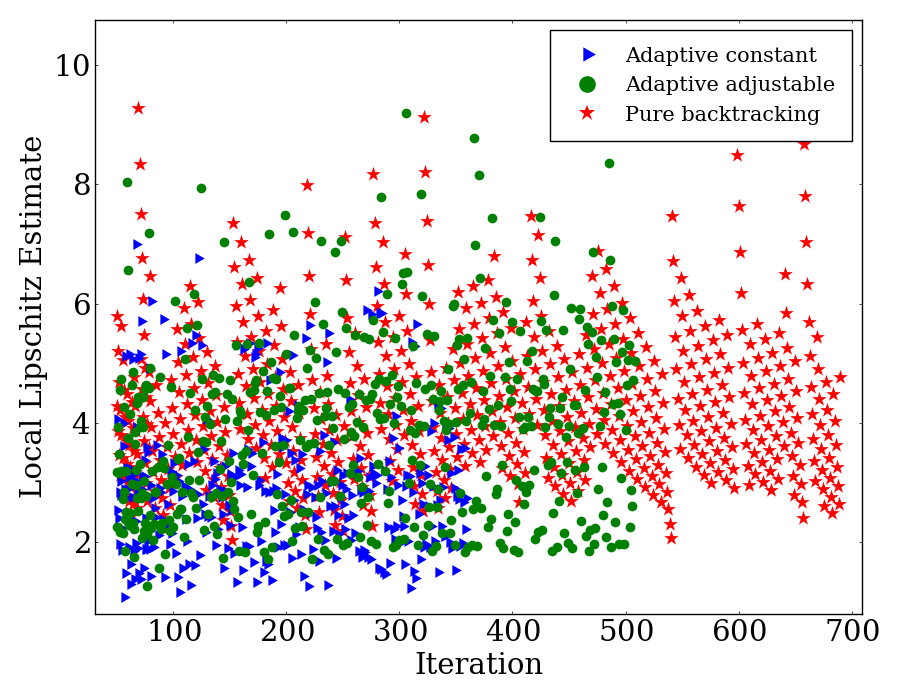

✅ Saved: MatrixFactorization_FWGap.eps


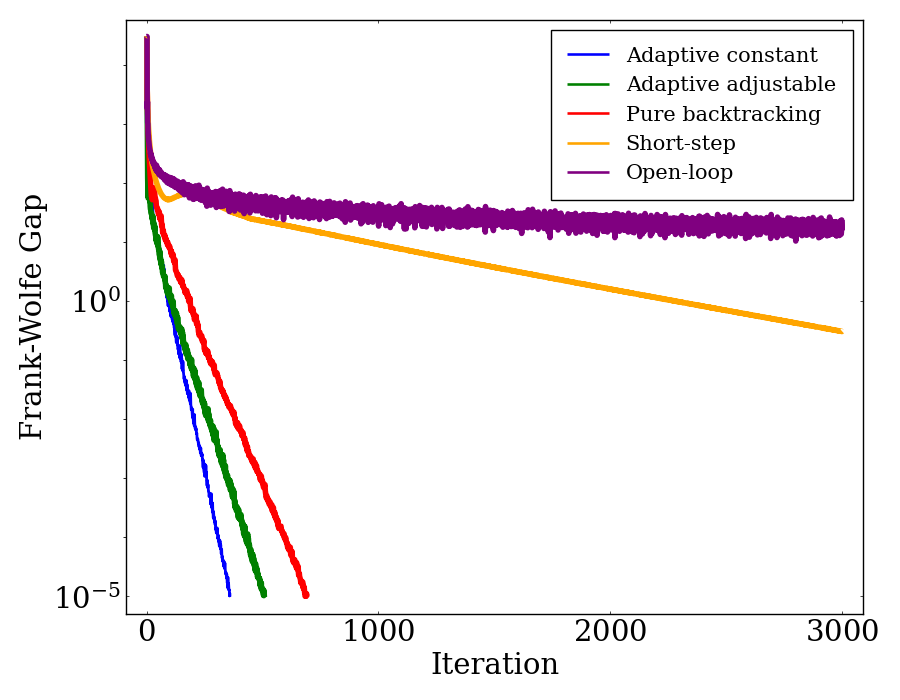

✅ Saved: MatrixFactorization_FWGap_vs_time.eps


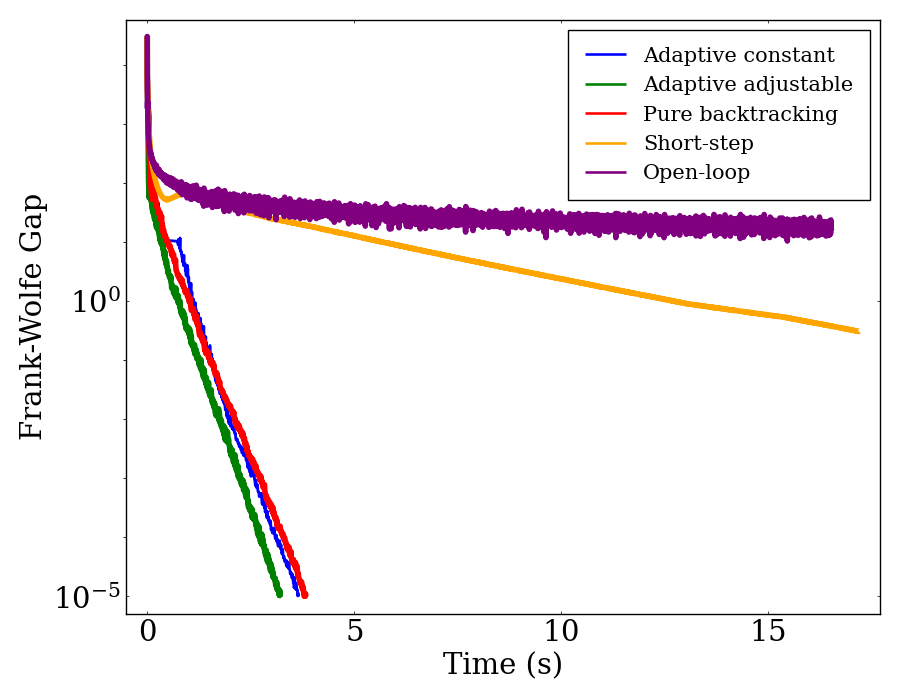


🎉 All plots saved as EPS in: /content/output_matfac


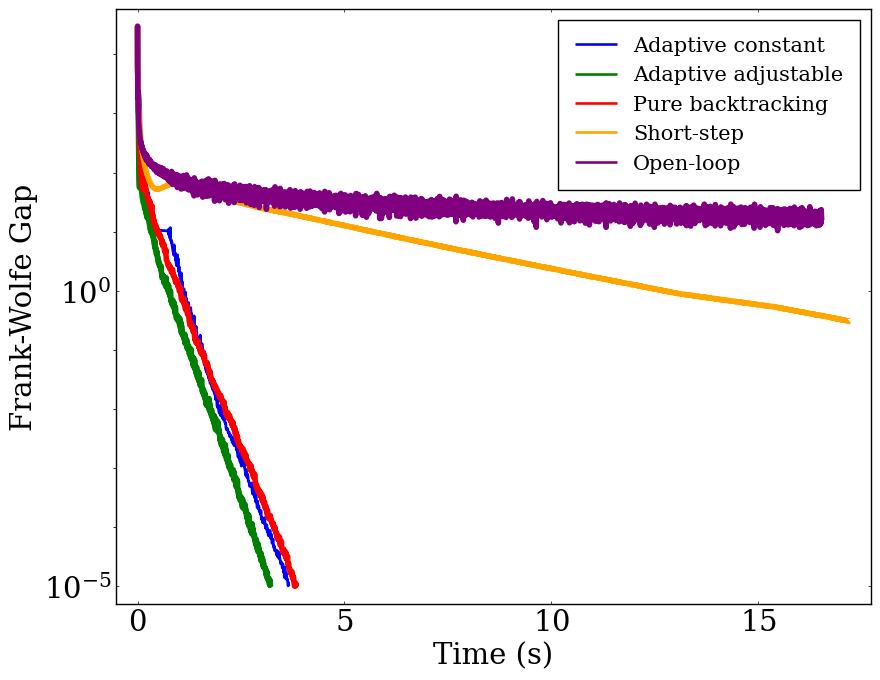

In [ ]:
# Ensure all necessary packages are loaded
using MAT
using Plots
using PyPlot
using Plots.Measures
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output_matfac"
mkpath(output_dir)

# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
open = matread(joinpath(output_dir, "results_open.mat"))
short = matread(joinpath(output_dir, "results_L.mat"))

# --- PRINT SUMMARY TABLE ---
println("\n# Summary of Results:\n")
println("Method               Iterations    Time (s)   Objective     Frank-Wolfe Gap")
println("───────────────────  ──────────  ──────────  ───────────  ───────────")

# Adaptive constant
iter_our = length(our["values"]) - 1
time_our = round(sum(our["times"]), digits=2)
obj_our  = round(our["values"][end], digits=4)
gap_our  = round(our["gaps"][end], digits=4)
println(rpad("Adaptive constant", 20), lpad(iter_our, 11), "  ", lpad(time_our, 10), "  ", lpad(obj_our, 11), "  ", lpad(gap_our, 11))

# Adaptive adjustable
iter_our5 = length(our5["values"]) - 1
time_our5 = round(sum(our5["times"]), digits=2)
obj_our5  = round(our5["values"][end], digits=4)
gap_our5  = round(our5["gaps"][end], digits=4)
println(rpad("Adaptive adjustable", 20), lpad(iter_our5, 11), "  ", lpad(time_our5, 10), "  ", lpad(obj_our5, 11), "  ", lpad(gap_our5, 11))

# Pure backtracking
iter_ped = length(ped["values"]) - 1
time_ped = round(sum(ped["times"]), digits=2)
obj_ped  = round(ped["values"][end], digits=4)
gap_ped  = round(ped["gaps"][end], digits=4)
println(rpad("Pure backtracking", 20), lpad(iter_ped, 11), "  ", lpad(time_ped, 10), "  ", lpad(obj_ped, 11), "  ", lpad(gap_ped, 11))

# Short-step  ← ✅ ADDED
iter_short = length(short["values"]) - 1
time_short = round(sum(short["times"]), digits=2)
obj_short  = round(short["values"][end], digits=4)
gap_short  = round(short["gaps"][end], digits=4)
println(rpad("Short-step", 20), lpad(iter_short, 11), "  ", lpad(time_short, 10), "  ", lpad(obj_short, 11), "  ", lpad(gap_short, 11))

# Open-loop
iter_open = length(open["values"]) - 1
time_open = round(sum(open["times"]), digits=2)
obj_open  = round(open["values"][end], digits=4)
gap_open  = round(open["gaps"][end], digits=4)
println(rpad("Open-loop", 20), lpad(iter_open, 11), "  ", lpad(time_open, 10), "  ", lpad(obj_open, 11), "  ", lpad(gap_open, 11))

println("\nAll computations and plotting complete. Check $output_dir for results.")


#________________________ PLOTTING _______________________________________#
function create_and_save_plots()

    # Compute gaps
    our_gaps   = our["gaps"]
    our5_gaps  = our5["gaps"]
    ped_gaps   = ped["gaps"]
    open_gaps  = open["gaps"]
    short_gaps = short["gaps"]

    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times   = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times  = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times   = [0.0; cumsum(ped["times"][1:end-1])]
    open_cum_times  = [0.0; cumsum(open["times"][1:end-1])]
    short_cum_times = [0.0; cumsum(short["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (21, "serif"),
        :guidefont => (21, "serif"),
        :tickfont => (21, "serif"),
        :legendfont => (15, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # ========================
    # PLOT 1: Lipschitz Constants
    # ========================
    p1 = Plots.plot()

    # Plot RED first (hidden from legend initially)
    Plots.plot!(p1, 50:length(ped["L_ks"]), ped["L_ks"][20:end],
                label=false, color=:red, seriestype=:scatter,
                markersize=11, marker=:star5, markerstrokewidth=0)

    # Plot BLUE — appears in legend
    Plots.plot!(p1, 50:length(our["L_ks"]), our["L_ks"][20:end],
                label="Adaptive constant", color=:blue, seriestype=:scatter,
                markersize=0.1, marker=:rtriangle, markerstrokewidth=0)

    # Plot GREEN — appears in legend
    Plots.plot!(p1, 50:length(our5["L_ks"]), our5["L_ks"][20:end],
                label="Adaptive adjustable", color=:green, seriestype=:scatter,
                markersize=0.1, marker=:circle, markerstrokewidth=0)

    # Plot RED again — now add to legend
    Plots.plot!(p1, 50:length(ped["L_ks"]), ped["L_ks"][20:end],
                label="Pure backtracking", color=:red, seriestype=:scatter,
                markersize=7, marker=:star5, markerstrokewidth=0)

    # Replot BLUE (visible markers, no legend)
    Plots.plot!(p1, 50:length(our["L_ks"]), our["L_ks"][20:end],
                label=false, color=:blue, seriestype=:scatter,
                markersize=9, marker=:rtriangle, markerstrokewidth=0)

    # Replot GREEN (visible markers, no legend)
    Plots.plot!(p1, 50:length(our5["L_ks"]), our5["L_ks"][20:end],
                label=false, color=:green, seriestype=:scatter,
                markersize=7, marker=:circle, markerstrokewidth=0)

    Plots.plot!(p1, xlabel="Iteration", ylabel="Local Lipschitz Estimate",
        legend_background_color=:white, legend_foreground_color=:black,
        framestyle=:box; style...)

    Plots.savefig(p1, joinpath(output_dir, "MatrixFactorization_L.eps"))
    println("✅ Saved: MatrixFactorization_L.eps")
    display(p1)

    # ========================
    # PLOT 2: Frank-Wolfe Gap vs Iteration  ← ✅ ADDED SHORT-STEP
    # ========================
    p2 = Plots.plot(our_gaps,
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Frank-Wolfe Gap",
                    linewidth=4;
                    style...)

    Plots.plot!(p2, our5_gaps,
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p2, ped_gaps,
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p2, short_gaps,           # ← ✅ ADDED SHORT-STEP
                    label="Short-step",
                    color=:orange,
                    markerstrokecolor=:orange,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p2, open_gaps,
                    label="Open-loop",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "MatrixFactorization_FWGap.eps"))
    println("✅ Saved: MatrixFactorization_FWGap.eps")
    display(p2)

    # ========================
    # PLOT 3: Frank-Wolfe Gap vs Time
    # ========================
    p3 = Plots.plot(our_cum_times[1:length(our_gaps)], our_gaps,
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    yscale=:log10,
                    linewidth=4,
                    xlabel="Time (s)",
                    ylabel="Frank-Wolfe Gap";
                    style...)

    Plots.plot!(p3, our5_cum_times[1:length(our5_gaps)], our5_gaps,
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p3, ped_cum_times[1:length(ped_gaps)], ped_gaps,
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p3, short_cum_times[1:length(short_gaps)], short_gaps,  # ← ✅ FIXED: was open_gaps
                    label="Short-step",
                    color=:orange,
                    markerstrokecolor=:orange,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p3, open_cum_times[1:length(open_gaps)], open_gaps,
                    label="Open-loop",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p3, joinpath(output_dir, "MatrixFactorization_FWGap_vs_time.eps"))
    println("✅ Saved: MatrixFactorization_FWGap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---
create_and_save_plots()

In [ ]:
# Step 1: Zip the correct output folder
import Pkg; Pkg.add("PyCall")
try
    run(`zip -r /content/output_matfac.zip /content/output_matfac`)
    println("Zipping successful!")
catch e
    println("Error during zipping: ", e)
end

# Step 2: Download
using PyCall
@pyimport google.colab.files as colab_files

try
    println("Preparing to download...")
    colab_files.download("/content/output_matfac.zip")
catch e
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")
end

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


updating: content/output_matfac/ (stored 0%)
updating: content/output_matfac/results_FW_Pedregosa.mat (deflated 9%)
updating: content/output_matfac/Sigmoida1a_L.eps (deflated 71%)
updating: content/output_matfac/Matrix_PrimalGap.eps (deflated 63%)
updating: content/output_matfac/results_open.mat (deflated 11%)
updating: content/output_matfac/MatrixFactorization_L.eps (deflated 71%)
updating: content/output_matfac/results_FW_OUR_5.mat (deflated 9%)
updating: content/output_matfac/Matrix_FWGap.eps (deflated 61%)
updating: content/output_matfac/MatrixFactorization_FWGap_vs_time.eps (deflated 59%)
updating: content/output_matfac/results_FW_OUR.mat (deflated 7%)
updating: content/output_matfac/Matrix_PrimalGap_vs_time.eps (deflated 61%)
updating: content/output_matfac/Matrix_L.eps (deflated 71%)
updating: content/output_matfac/Matrix_FWGap_vs_time.eps (deflated 59%)
updating: content/output_matfac/MatrixFactorization_FWGap.eps (deflated 60%)
updating: content/output_matfac/Sigmoida1a_Gap_vs